In [1]:
import karateclub as kc
import matplotlib.pyplot as plt
import networkx as nx
from networkx.drawing.nx_pydot import graphviz_layout
import numpy as np
import os
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import pydot
import random
import warnings

from reeb_utils import collapse_traj, do_reeb_for_start_end, do_reeb_for_explore_node
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score


warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## Load data

In [2]:
# load data into dataframe
df = pd.read_csv("data/MLINDIV_train_full.csv")

test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")

## EXPLORE DF
explore_df = df[df["eprocs"].str.contains("Explore")]

# By quartile
q_dict = {}
acc_dict = {}
for index, row in test_df[["Subject", "quartile", "subj_mean_acc"]].iterrows():
    subj, q, acc = row["Subject"], row["quartile"], row["subj_mean_acc"]
    if subj not in q_dict:
        q_dict[subj] = q
        acc_dict[subj] = acc

explore_df["quartile"] = explore_df["Subject"].map(q_dict)
explore_df["subject_mean_acc"] = explore_df["Subject"].map(acc_dict)

def compute_extended_explore_traj(e_path):
    # need to replace V-east (V2) with Y and F-south (F3) with N
    # because they are facing and can see the object from there
    path = e_path.replace("V2", "Y2")
    path = e_path.replace("F3", "N3")
    
    nodes = path.split()
    nodes.remove("NA")
    nodes = [n[0] for n in nodes]

    return "".join(nodes)
    
def compute_explore_traj(e_path):
    # need to replace V-east (V2) with Y and F-south (F3) with N
    # because they are facing and can see the object from there
    path = e_path.replace("V2", "Y2")
    path = e_path.replace("F3", "N3")
    
    nodes = path.split()
    nodes.remove("NA")
    nodes = [n[0] for n in nodes]

    return "".join(collapse_traj(nodes))

# concatenate explore rounds for now
explore_df["explore_path"] = explore_df.groupby("Subject")["e_paths"].transform(" ".join)
explore_df = explore_df.drop_duplicates(subset=["Subject"], keep="first")

explore_df["extended_explore_traj"] = explore_df["explore_path"].apply(compute_extended_explore_traj)
explore_df["explore_traj"] = explore_df["explore_path"].apply(compute_explore_traj)
explore_df["num_nodes_visited"] = explore_df["explore_traj"].apply(len)

explore_df[["explore_traj", "quartile", "subject_mean_acc"]]

,explore_traj,quartile,subject_mean_acc
0,URQTXVXZPZXTQHGLGAGHBCICDEMOMSRUTXTUWUTXVYVXZP...,3.0,0.916667
50,RSMOMEDJKJRUWUTQRQTXVYVXZPZXTQHGLGAGHBCICDEMOM...,4.0,1.000000
100,URQTXZPZXVXTURSMEFNFEDCICBHQHGAGLGHBCDJRJKJRUR...,2.0,0.375000
110,UWURSMEFNFEDCBHGLGHGAGHQTXVYVXZPZXTUWURQHGAGLG...,3.0,0.791667
160,DJRUWUTXVYVXZPZXTQRSMEFNFEDJRQHGLGAGHQTXVXZXTU...,1.0,0.229167
...,...,...,...
4837,RJDCBHQTXVYVXTURJDEFNFEDCBHQTXVXZPZXTUWURSMEDC...,1.0,0.125000
4887,URJDCBHGAGLGHQTXZPZXVXTUWURSMEFNFEDCBHGAGHQRJK...,2.0,0.375000
4937,DJKJRQHBHGAGHQTXVYVXTQRSMOMSRJDEFNFEMSRUWUTXVX...,2.0,0.416667
4987,RJDCICDEMOMSRJKJDCBHGLGHQRUWUTXVYVXZPZXTQHGAGL...,3.0,0.854167


### Load Subject Info

In [3]:
subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
subject_df = subject_df[~subject_df["Subject"].isna()]

subject_df["is_man"] = (subject_df["Sex"] == "M")

merged_df = pd.merge(explore_df, subject_df, on="Subject")
merged_df[["Sex", "Proportion Correct (new version)", "subject_mean_acc"]]

,Sex,Proportion Correct (new version),subject_mean_acc
0,F,0.916667,0.916667
1,M,1.000000,1.000000
2,F,0.375000,0.375000
3,M,0.791667,0.791667
4,F,0.229167,0.229167
...,...,...,...
70,F,0.125000,0.125000
71,M,0.375000,0.375000
72,M,0.416667,0.416667
73,M,0.854167,0.854167


## Explore-treeb specific functions

In [5]:
from reeb_utils import all_traj_same

def simplify_path(path):
    nodes_visited = path.split()[:-1]
    
    simplified = ""
    for i in range(len(nodes_visited)-1):
        rt = {1:2, 2:3, 3:4, 4:1}
        lt = {2:1, 1:4, 4:3, 3:2}

        curr_node, next_node = nodes_visited[i], nodes_visited[i+1]
        if curr_node[0] != next_node[0]:
            # forward press
            simplified += "F"
        elif rt[int(curr_node[1])] == int(next_node[1]):
            # right turn
            simplified += "R"
        elif lt[int(curr_node[1])] == int(next_node[1]):
            # left turn
            simplified += "L"
        else:
            # print(curr_node, next_node)
            simplified += "R"
            ## N3 N1 spin
            # print("FUCK ME")
        
    return simplified

def generate_reeb_tree(start_i, start_node, trajs, which_trajs, G, visited, SUCCESS="", DEBUG=False):
    """Generates Reeb tree.

    TODO talk about what this means

    Parameters
    ----------
    start_i : TODO,
        TODO
    start_node : TODO,
        TODO
    trajs : list,
        Shape = [n_trajs, various]
        List of all trajectories over which to compute the Reeb tree.
    G : nx.Graph,
        Reeb tree to mutate in place as graph is construted.
    visited : TODO,
        TODO
    DEBUG : boolean,
        If True print more things.

    Returns
    -------
    None
    """
    if DEBUG: print(f"DO REEB, {start_i}, {start_node}, {which_trajs}")
    times_before = visited.get(start_node, 0) 
    visited[start_node] = times_before
    to_add = start_node + "_" + str(times_before)

    max_traj_len = max([len(trajs[t]) for t in which_trajs])

    ## BASE CASE 1: SINGLETON ##
    ## BASE CASE 2: ALL THE SAME ##
    if len(which_trajs) == 1 or all_traj_same(trajs, which_trajs, max_traj_len):
        end_node = trajs[which_trajs[0]][-1]
        times_before = visited.get(end_node, -1) + 1
        visited[end_node] = times_before
        
        end_node +=  "_" + str(times_before)
        if DEBUG: print(f"BASE CASE: {which_trajs}, last: {end_node}")

        color = "green" if SUCCESS in end_node else "yellow"
        G.add_node(end_node, color=color, end=True)
        G.add_edge(to_add, end_node, weight=len(which_trajs) / len(trajs))

        return
    

    ## RECURSIVE STEP ##
    if DEBUG: print(f"FOR LOOP, {start_i}, {which_trajs}")
    for step in range(start_i, max_traj_len):
        
        new_gn = {}
        for i in which_trajs:
            traj = trajs[i]

            ## STOPPING CONDITION FOR THIS ONE GUY ##
            if step >= len(traj): 
                new_gn["DONE"] = new_gn.get("DONE", []).copy() + [i]
            else:
                new_node = traj[step]     
                new_gn[new_node] = new_gn.get(new_node, []).copy() + [i]

        if DEBUG: print("NEW_GN", new_gn)
        # decide whether we need a reeb node
        
        # people went different ways!!
        if len(new_gn.keys()) > 1:
            times_before = visited.get(start_node, 0)
            sn = start_node + "_" + str(times_before)
            
            

            if DEBUG: print("VISITED", visited)
            
            for k, v in new_gn.items():
                if DEBUG: print("RECURSE")

                # the thing happened at the node before this! all the paths in this fn are at the same point there so it doesnt mattter
                old_one = k#trajs[which_trajs[0]][step-1]
                times_before = visited.get(old_one, -1) + 1
                visited[old_one] = times_before

                

                on = k + "_" + str(times_before)
                G.add_node(on, color="blue", end=False)
                if DEBUG: print(f"ADDING NEW BLUE NODE {on}")
                
                G.add_edge(sn, on, weight=len(which_trajs) / len(trajs))
                if DEBUG: print(f"ADDING NEW EDGE from {sn} to {on}, weight is {len(which_trajs)}")

                if DEBUG and k == "DONE":
                    print("*@#)$*$#()*(#@($")
                    print(new_gn)
                    
                generate_reeb_tree(step+1, old_one, trajs,  v, G, visited, SUCCESS=SUCCESS, DEBUG=DEBUG)

            return

In [6]:
def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Number of Edges
    num_edges = graph.number_of_edges()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Average Node Degree
    avg_degree = np.mean([degree for node, degree in graph.degree()])
    
    # Diameter
    diameter = nx.diameter(graph)
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Average Path Length
    avg_path_length = nx.average_shortest_path_length(graph)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Put all features in a list
    features = [
        num_nodes,
        num_edges,
        depth,
        avg_degree,
        diameter,
        num_leaves,
        avg_path_length,
        avg_branching_factor
    ]
    
    return features

## Calculate paths before and after finding all objects

In [7]:
def find_when_all_objects_found(traj):    
    OBJECTS = "ALPIKNOWY" 
    # could take max of [traj.index(obj) for obj in OBJECTS]
    # but raises ValueError if obj not found & is slower bc runs through list multiple times

    for i, node in enumerate(traj):
        if node in OBJECTS:
            OBJECTS = OBJECTS.replace(node, "")
            
            # found all objects
            if len(OBJECTS) == 0:
                return i
    return "DNF-" + str(OBJECTS)

explore_df["all_objects_found_idx"] = explore_df["extended_explore_traj"].apply(find_when_all_objects_found)

print(explore_df[["extended_explore_traj", "e_paths", "quartile", "subject_mean_acc", "all_objects_found_idx"]])

# plt.scatter(explore_df["all_objects_found_idx"], explore_df["subject_mean_acc"])
# plt.show()

                                  extended_explore_traj  \
0     UURRQQTTXXXXVVXZPPZXTTQHHGGLLGAAGGHHBBCCICCDEE...   
50    RRSSMMOMMEEDDJJKJJRRRUUWUTTQQRRRQQTTXXVYYVXZPP...   
100   UURRQQTTXZPPZXXVVXXTUURRSSMEEEEFNFEDCCICCBBHQQ...   
110   UWUURRSSMEEFNNNFFEDCBBHHGGLLGGHHHGGAAGGHHQTTXX...   
160   DDJRUUWUTXXVYYVXZPPZXTTQQRSSMEEFNNNFFEEEEEDDJR...   
...                                                 ...   
4837  RJDDCBBHQTTXXVYYVVVXXTUURJDDEFNNNFFEDCBBHQTTXX...   
4887  UURJDDCBBHHGGAAGLLGGHHQTTXZPPZXXVVXXTUWUURRSSM...   
4937  DDJJKJJRRQQHBBBHHGGAAGGHHQTTXXVYYVXXTTQQRSSMMO...   
4987  RRRRRJJJDDDDCCICCDEEMMOMMSSRRJJKJJDDCBBHHGGGGL...   
5037  HHGGLLGAAGGHHBBCDEEMMOMMSSRRUUTTTXXVYYVXXTTQQR...   

                                                e_paths  quartile  \
0     U2 U1 R1 R4 Q4 Q3 T3 T4 X4 X3 X2 X3 V2 V1 X1 Z...       3.0   
50    R1 R2 S2 S1 M1 M4 O2 M2 M1 E1 E4 D4 D3 J3 J2 K...       4.0   
100   U2 U1 R1 R4 Q4 Q3 T3 T4 X4 Z1 P2 P3 Z2 X2 X3 V...       2.0   
110   U2 W4 U4 

## Create explore treebs

In [8]:
salient_node = "F"
etreebs = []
baseline_features = []
qs = []
accs = []
traj_lens = []
sexes = []
for i, row in merged_df.iterrows():
    path = row["e_paths"]
    # print(path)
    simplified_path = simplify_path(path)
    # print(simplified_path)
    trajs = []
    for i in range(len(simplified_path)):
        if salient_node == simplified_path[i]: # in path[i]:# if i%5 == 0:
            trajs.append(simplified_path[i: i+10])
    
    traj_lens.append(len(trajs))
    # trajs = trajs[:25]
    # print(trajs)
    
    G = nx.Graph()
    G.add_node(salient_node + "_0", color="red", end=False)
    
    if len(trajs) != 0:
        visited = {}
        generate_reeb_tree(0, salient_node, trajs, [i for i in range(len(trajs))], G, visited, SUCCESS="IMPOSSIBLE", DEBUG=False)
    
    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero

    etreebs.append(new_G.copy())

    if row["quartile"]:
        qs.append(row["quartile"])
    else:
        qs.append(1)

    sexes.append(int(row["is_man"]))

    accs.append(row["subject_mean_acc"])
    baseline_features.append([len(path)])
    # print(G.edges)
    # break

baseline_features = np.array(baseline_features)
print(min(traj_lens))

57


### Visualisation

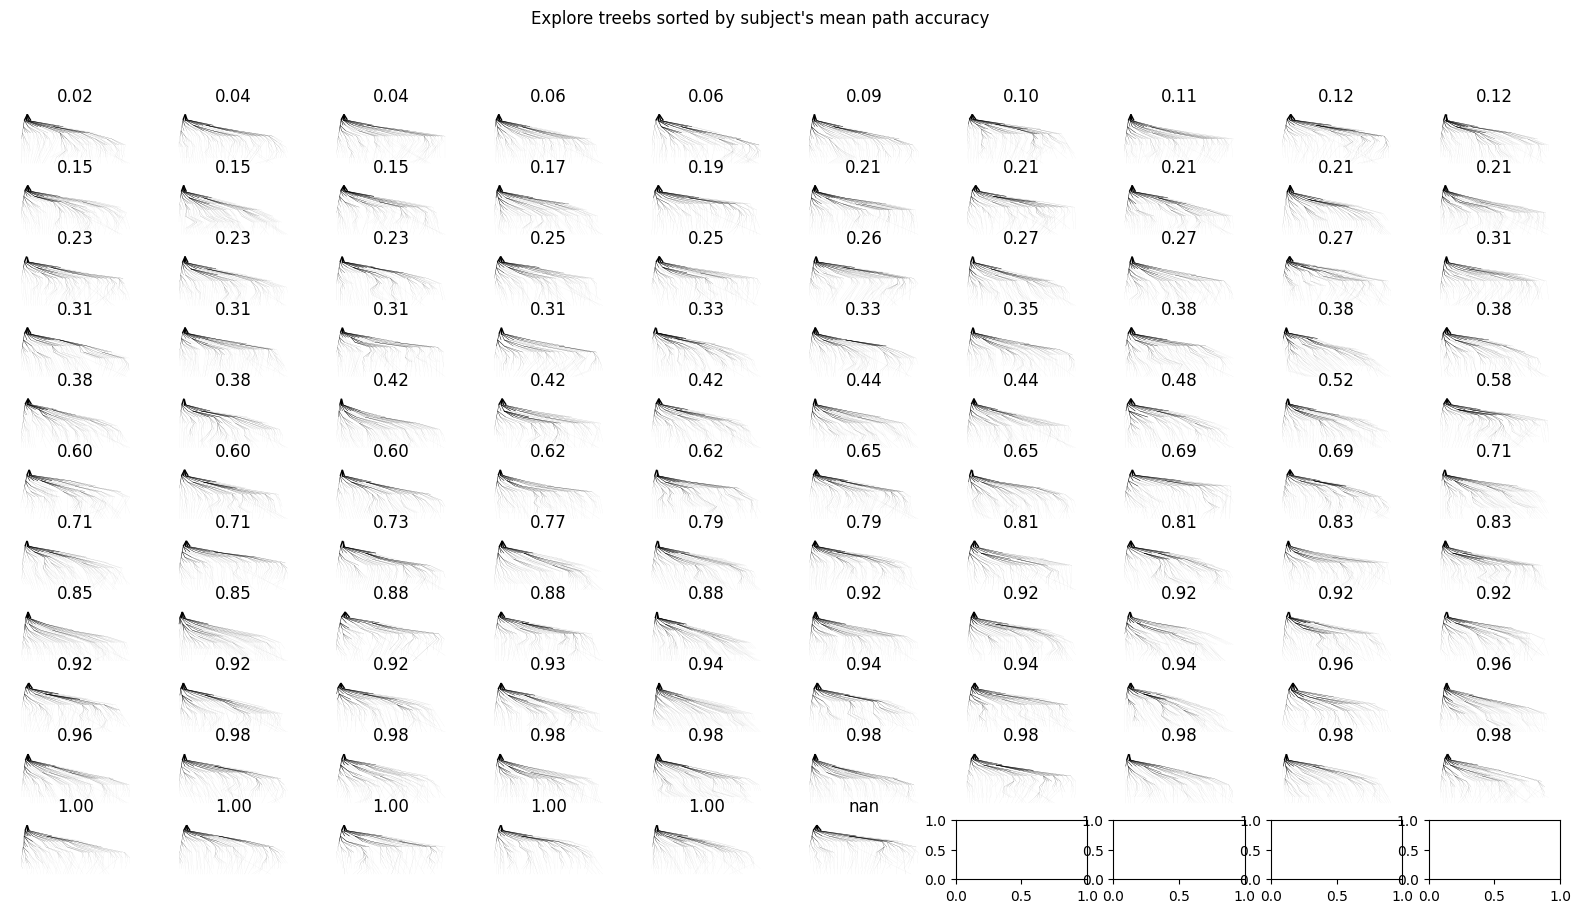

In [359]:
fig, axes = plt.subplots(11, 10, figsize=(20,10))

sorted_order = sorted(range(len(accs)), key=lambda x: (pd.isna(accs[x]), float(accs[x]) if not pd.isna(accs[x]) else float('inf')))
for i, tree_index in enumerate(sorted_order):
    G = etreebs[tree_index]    
    ax = axes[i // 10][i % 10]
    pos = graphviz_layout(G, prog="dot")
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * 1.0 for u,v in edges]

    nodes = G.nodes()
    # print(nodes)
    # print(edges)
    n_labels = {n: n for n in G}
    n_colors = [G.nodes[n].get("color", "blue") for n in nodes]

    # nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=500, alpha=0.7, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=ax)
    # nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=13, ax=ax) # font_weight="bold",

    ax.axis("off")
    ax.set_title(f"{accs[tree_index]:.2f}")

    # if i > 5: break

fig.suptitle("Explore treebs sorted by subject's mean path accuracy")
fig.savefig("figures/explore_treebs_by_acc.png")

plt.show()

FFRFLLFFLFFLRRLLFFRRRLLLFRRLFFRRFFLRLRFLLLLLFRFRFRLFLRRLLRLFFLRRLFRRLFLFFRLFFLFRRRRRLFLFRLFFLFRLLFFFLLLRFLLRLRFLFRLFFFRFRLFRFRLLFRFFLRFLRRFFLLRLRFFFLL
['FLFLFFLFLF', 'FLFFLFLFLF', 'FFLFLFLFRF', 'FLFLFLFRFF', 'FLFLFRFFFR', 'FLFRFFFRFR', 'FRFFFRFRFF', 'FFFRFRFFRF', 'FFRFRFFRFR', 'FRFRFFRFRF', 'FRFFRFRFLF', 'FFRFRFLFRF', 'FRFRFLFRFR', 'FRFLFRFRLF', 'FLFRFRLFLF', 'FRFRLFLFFR', 'FRLFLFFRFF', 'FLFFRFFRFL', 'FFRFFRFLFR', 'FRFFRFLFRF', 'FFRFLFRFFL', 'FRFLFRFFLF', 'FLFRFFLFLF', 'FRFFLFLFFL', 'FFLFLFFLFR', 'FLFLFFLFRF', 'FLFFLFRFRF', 'FFLFRFRFRF', 'FLFRFRFRFL', 'FRFRFRFLFL', 'FRFRFLFLFR', 'FRFLFLFRFF', 'FLFLFRFFLF', 'FLFRFFLFLF', 'FRFFLFLFFL', 'FFLFLFFLRF', 'FLFLFFLRFL', 'FLFFLRFLFF', 'FFLRFLFFFR', 'FLRFLFFFRF', 'FLFFFRFLFL', 'FFFRFLFLFF', 'FFRFLFLFFR', 'FRFLFLFFRL', 'FLFLFFRLFR', 'FLFFRLFRFF', 'FFRLFRFFFL', 'FRLFRFFFLF', 'FRFFFLFRLF', 'FFFLFRLFLF', 'FFLFRLFLFL', 'FLFRLFLFLF', 'FRLFLFLFLF', 'FLFLFLFRFL', 'FLFLFRFLFR', 'FLFRFLFRFF', 'FRFLFRFFRF', 'FLFRFFRFFF', 'FRFFRFFFLF', 'FFRFFFLFFF', 'FRFFFLF

IndexError: list index out of range

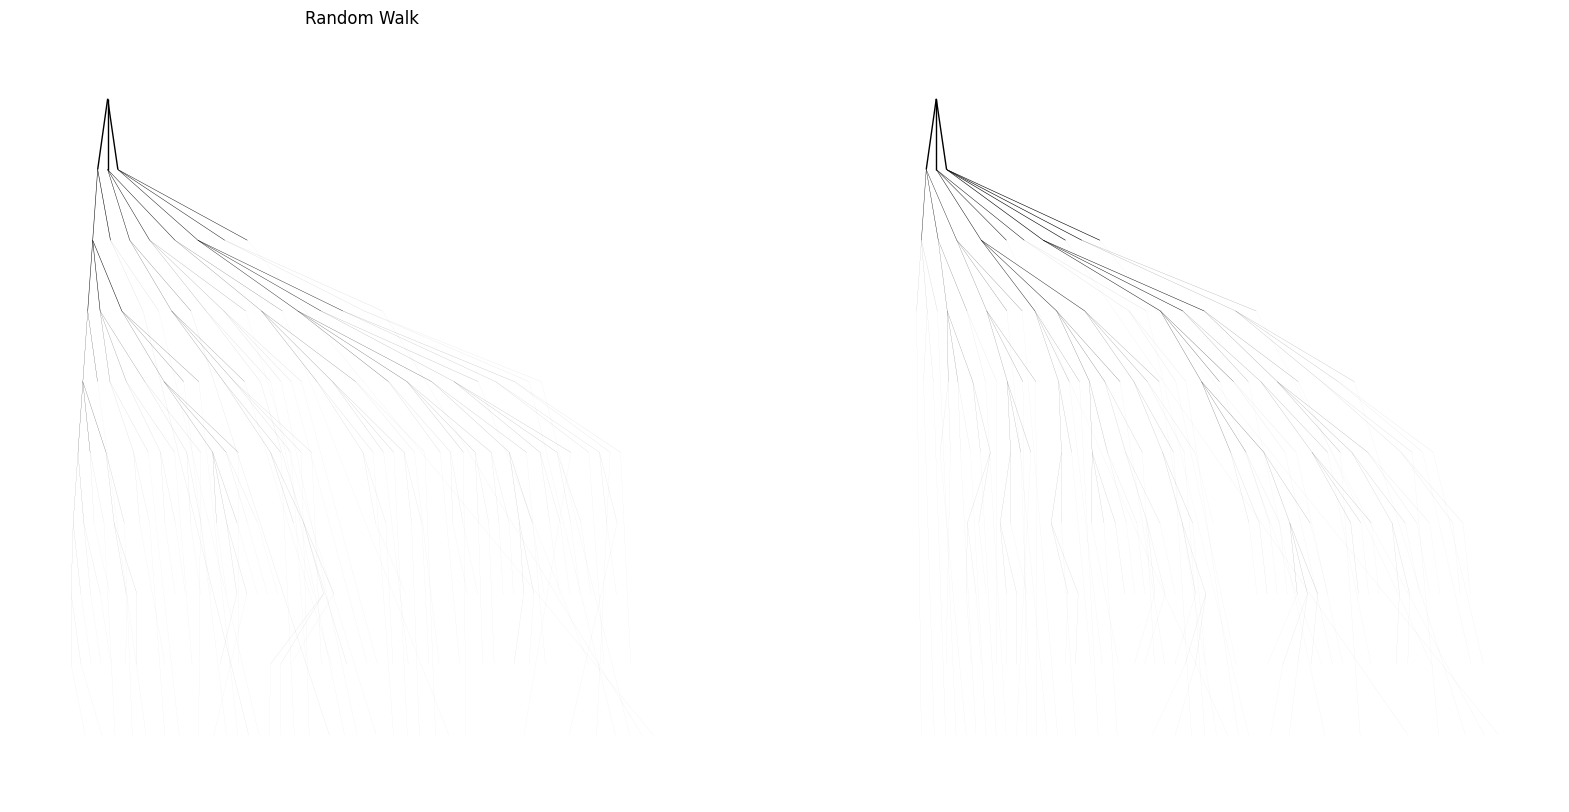

In [430]:
import random

## random boy & plot
random_str = ''.join(random.choices(["F", "R", "L"], k=150))
print(random_str)

trajs = []
for i in range(len(simplified_path)):
    if salient_node == simplified_path[i]: # in path[i]:# if i%5 == 0:
        smidge = simplified_path[i: i+10]
        if len(smidge) == 10:
            trajs.append(smidge)
print(trajs)

random_G = nx.Graph()
random_G.add_node(salient_node + "_0", color="red", end=False)

if len(trajs) != 0:
    visited = {}
    generate_reeb_tree(0, salient_node, trajs, [i for i in range(len(trajs))], random_G, visited, SUCCESS="IMPOSSIBLE", DEBUG=False)


fig, axes = plt.subplots(1, 2, figsize=(20,10))

ax = axes[0]
pos = graphviz_layout(random_G, prog="dot")
    
edges = random_G.edges()
print(edges)
weights = [random_G[u][v]['weight'] * 1.0 for u,v in edges]
print(weights)
    
nodes = random_G.nodes()

# nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=500, alpha=0.7, ax=ax)
nx.draw_networkx_edges(random_G, pos, edgelist=edges, width=weights, ax=ax)
# nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=13, ax=ax) # font_weight="bold",

ax.axis("off")
ax.set_title(f"Random Walk")


G = etreebs[12]
ax = axes[1]
pos = graphviz_layout(G, prog="dot")
    
edges = G.edges()
weights = [G[u][v]['weight'] * 1.0 for u,v in edges]

nodes = G.nodes()

# nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=500, alpha=0.7, ax=ax)
nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=ax)
# nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=13, ax=ax) # font_weight="bold",

ax.axis("off")
ax.set_title(f"{accs[tree_index]:.2f}")


## Compute before/after treebs

In [432]:
salient_node = "F"
etreebs = []
qs = []
accs = []
traj_lens = []
before_after = []
baseline_features = []

j=0
for i, row in explore_df.iterrows():
    whole_path = row["e_paths"]
    split_i = row["all_objects_found_idx"]

    if type(split_i) is str:
        path = whole_path
        if path[-1] == "NA": path.pop(-1)
        simplified_path = simplify_path(path)
        
        trajs = []
        for i in range(len(simplified_path)):
            if simplified_path[i] == salient_node:# if i%5 == 0:
                smidge = simplified_path[i: i+5]
                if len(smidge) == 5:
                    trajs.append(smidge)
                
        G = nx.Graph()
        G.add_node(salient_node + "_0", color="red", end=False)
        
        if len(trajs) != 0:
            visited = {}
            generate_reeb_tree(0, salient_node, trajs, [i for i in range(len(trajs))], G, visited, SUCCESS="IMPOSSIBLE", DEBUG=False)
        
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
    
        etreebs.append(new_G.copy())
        j+=1
        # print(trajs)
        # plot_treeb(new_G)
    
        if row["quartile"]:
            qs.append(row["quartile"])
        else:
            qs.append(1)
    
        if not pd.isna(row["subject_mean_acc"]):
            accs.append(row["subject_mean_acc"])
        else:
            accs.append(0.5)    
        before_after.append(split_i)
        baseline_features.append([len(path)])
    
        traj_lens.append(len(trajs))

    else:
        ## BEFORE    
        path = whole_path[:split_i]
        simplified_path = simplify_path(path)
        
        trajs = []
        for i in range(len(simplified_path)):
            if simplified_path[i] == salient_node:# if i%5 == 0:
                smidge = simplified_path[i: i+5]
                if len(smidge) == 5:
                    trajs.append(smidge)
        
        # trajs = trajs[:25]
        
        G = nx.Graph()
        G.add_node(salient_node + "_0", color="red", end=False)
        
        if len(trajs) != 0:
            visited = {}
            generate_reeb_tree(0, salient_node, trajs, [i for i in range(len(trajs))], G, visited, SUCCESS="IMPOSSIBLE", DEBUG=False)
        
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
    
        etreebs.append(new_G.copy())
        j+=1
        # print(trajs)
        # plot_treeb(new_G)
    
        if row["quartile"]:
            qs.append(row["quartile"])
        else:
            qs.append(1)
    
        if not pd.isna(row["subject_mean_acc"]):
            accs.append(row["subject_mean_acc"])
        else:
            accs.append(0.5)    
        before_after.append("B")
        baseline_features.append([len(path)])
    
        traj_lens.append(len(trajs))
    
    
        ## AFTER    
        path = whole_path[split_i:]
        simplified_path = simplify_path(path)
        
        trajs = []
        for i in range(len(simplified_path)):
            if simplified_path[i] == salient_node:# if i%5 == 0:
                smidge = simplified_path[i: i+5]
                if len(smidge) == 5:
                    trajs.append(smidge)
        
        trajs = trajs[:traj_lens[-1]]
        traj_lens.append(len(trajs))
        
        G = nx.Graph()
        G.add_node(salient_node + "_0", color="red", end=False)
        
        if len(trajs) != 0:
            visited = {}
            # if j==81:
            #     print(trajs)
            #     generate_reeb_tree(0, salient_node, trajs, [i for i in range(len(trajs))], G, visited, SUCCESS="IMPOSSIBLE", DEBUG=True)
            # else:
            generate_reeb_tree(0, salient_node, trajs, [i for i in range(len(trajs))], G, visited, SUCCESS="IMPOSSIBLE", DEBUG=False)
        
        new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero
        # print(trajs)
        # plot_treeb(new_G)
    
        etreebs.append(new_G.copy())
        j+=1
    
        if row["quartile"]:
            qs.append(row["quartile"])
        else:
            qs.append(1)
    
        if not pd.isna(row["subject_mean_acc"]):
            accs.append(row["subject_mean_acc"])
        else:
            accs.append(0.5)
    
        before_after.append("A")
        baseline_features.append([len(path)])
    
        traj_lens.append(len(trajs))


# print(min(traj_lens))
baseline_features = np.array(baseline_features)

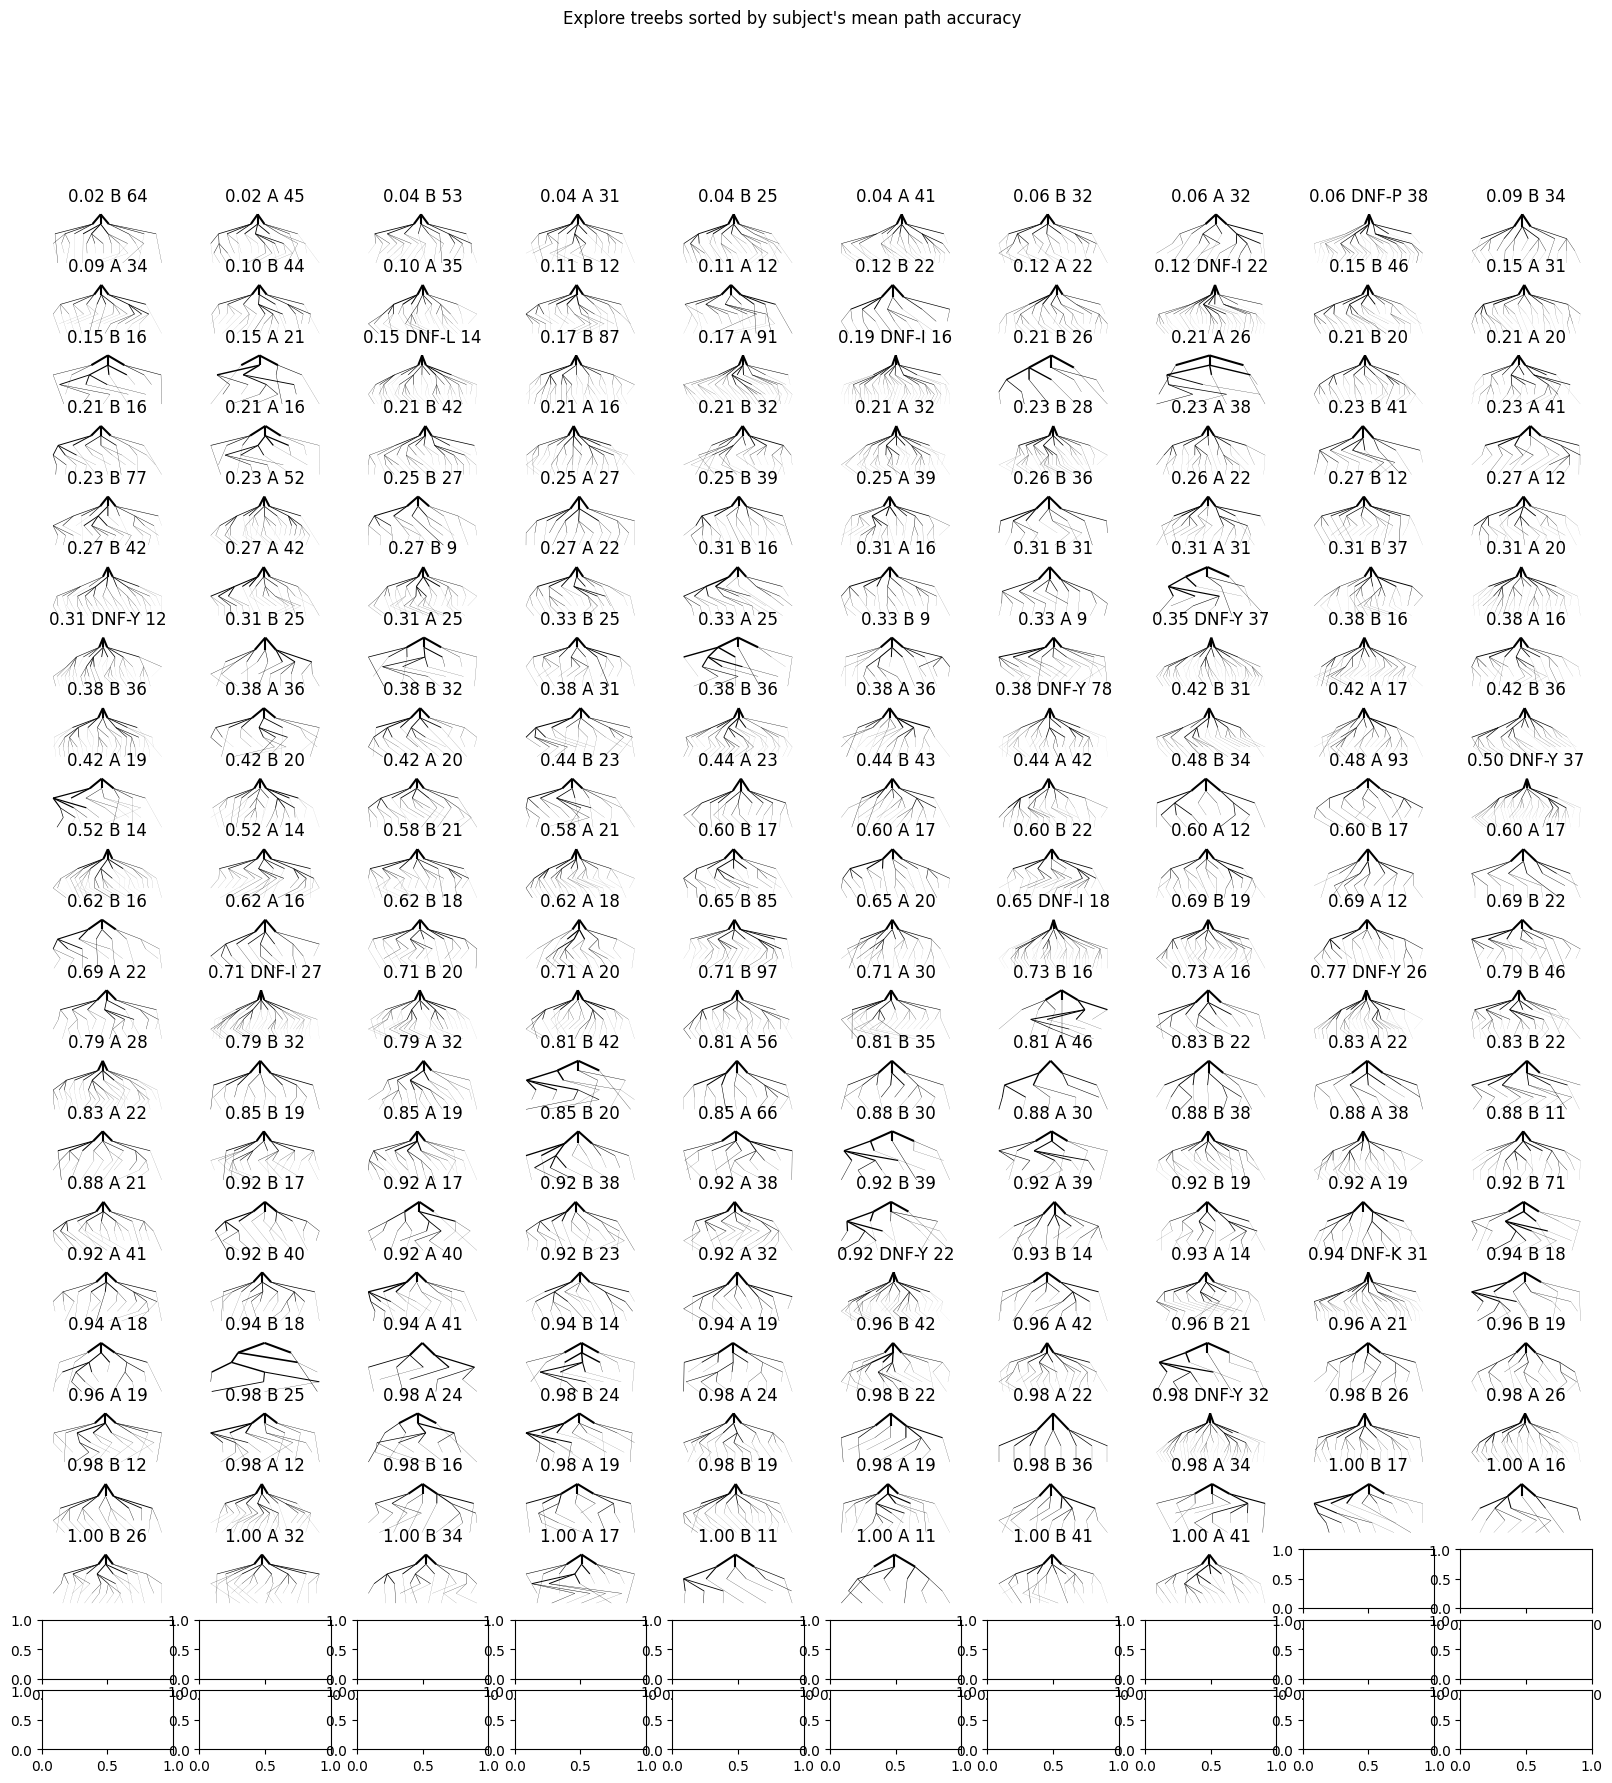

In [382]:
fig, axes = plt.subplots(22, 10, figsize=(20,20))

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
c=0
for i, tree_index in enumerate(sorted_order):
    G = etreebs[tree_index]

    # print(tree_index)
    
    ax = axes[i // 10][i % 10]
    pos = graphviz_layout(G, prog="dot")


    # MID ATTEMPT TO CENTRE TREES
    # Adjust the layout to center each level
    # Get y-levels (depths)
    levels = {}
    for node, (x, y) in pos.items():
        if y not in levels:
            levels[y] = []
        levels[y].append(node)
    
    # Center each level
    for y in levels:
        x_coords = [pos[node][0] for node in levels[y]]
        mean_x = np.mean(x_coords)
        centered_x_coords = [x - mean_x for x in x_coords]
        for i, node in enumerate(levels[y]):
            pos[node] = (centered_x_coords[i], y)

    edges = G.edges()
    weights = [G[u][v]['weight'] * 1.5 for u,v in edges]

    # nodes = G.nodes()
    # n_labels = {n: n for n in G}
    # n_colors = [G.nodes[n].get("color", "blue") for n in nodes]

    # nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=500, alpha=0.7, ax=ax)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=ax)
    # nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=13, ax=ax) # font_weight="bold",

    ax.axis("off")
    ax.set_title(f"{accs[tree_index]:.2f} {before_after[tree_index]} {traj_lens[tree_index]}")

    
    # if c>4:
    #     break
    # c += 1

fig.suptitle("Explore treebs sorted by subject's mean path accuracy")
plt.show()

In [377]:
fig.savefig("figures/explore_treebs_by_acc.png")

#### Plotting fn

In [48]:
def plot_treeb(G):
    fig = plt.figure(figsize=(10,5))
    this_ax = plt.gca()

    pos = graphviz_layout(G, prog="dot")
    
    edges = G.edges()
    weights = [G[u][v]['weight'] * .4 for u,v in edges]

    nodes = G.nodes()
    # for n in nodes:
    #     print(n, G.nodes[n])
    n_labels = {n: n for n in G}
    n_colors = [G.nodes[n].get("color", "blue") for n in nodes]
    # print(n_colors)
    # print ((q-1) // 2, (q-1) % 2)
    nx.draw_networkx_nodes(G, pos, node_color=n_colors, node_size=500, alpha=0.7, ax=this_ax)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=weights, ax=this_ax)
    # nx.draw_networkx_labels(G, pos, labels=n_labels, font_size=13, ax=this_ax) # font_weight="bold",

    this_ax.axis("off")
    plt.show()

## Graph embeddings & clustering

ARI: -0.01 (random would be: -0.02)
NMI: 0.00 (random would be: 0.00)
[0.35512668 0.0384775 ]
[[0.04548271 2.9675012  1.4347368  1.7079057  1.2425784  0.80356276
  2.649459   0.53269696 0.46971533 0.10157615 0.06976673 0.6537111
  1.662758   0.19425249 1.668858   1.5069637  1.299498   1.2227714
  3.2106524  2.0672848  0.6361714  0.59410363 1.0303574  1.4174669
  0.8260493  1.6755006  0.6603039  0.34520918 0.41540754 0.67334473
  1.5940521  1.5420507  1.0725062  0.0177574  0.04622608 1.0152812
  1.3782804  1.115541   1.9803393  0.28132224 0.73708683 0.606553
  0.09577747 0.6817732  1.3729515  1.0017078  2.8492758  0.57763803
  1.0642114  0.9393884  2.2452195  0.6508797  1.0119908  0.599931
  0.7082472  0.1199735  1.0063196  0.5727572  0.4782277  0.70355403
  0.12183817 1.6121936  0.74701875 0.5893202 ]
 [0.6253657  0.04030198 0.07656689 0.36542132 1.5815272  1.8456042
  0.9371081  0.01742482 2.1739483  2.296373   1.9924283  0.43697935
  0.64902055 1.8889469  2.1432939  2.1967883  0.3628

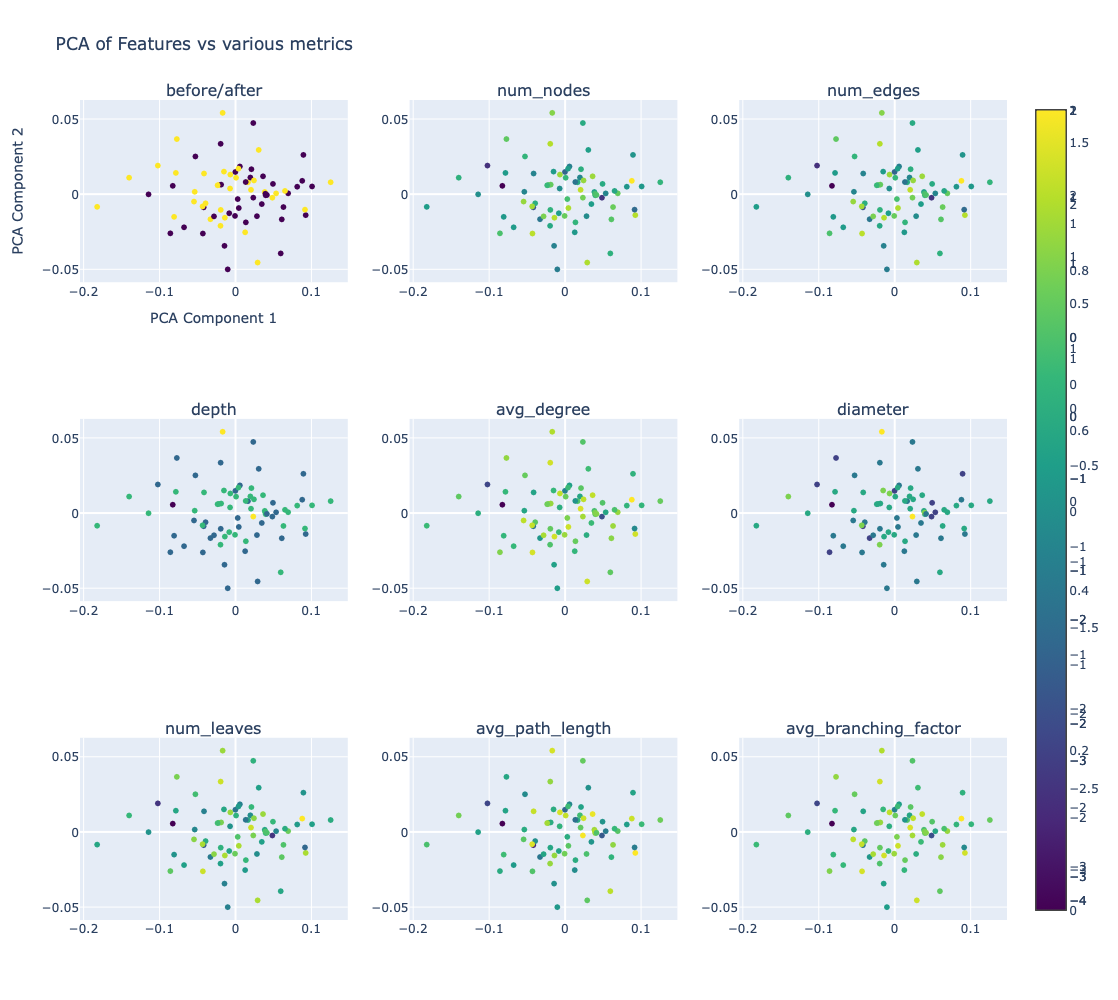

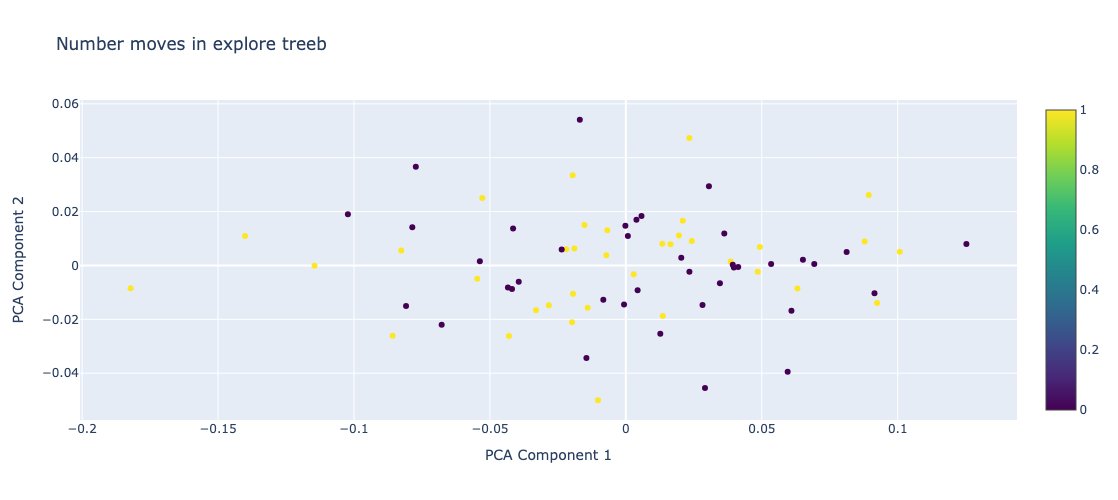

In [448]:
use_embeddings = True

tree_features = []
people = []
for i, graph in enumerate(etreebs):
    tree_features.append(extract_tree_features(graph, 0))
    people.append(i)
tree_features = np.array(tree_features)

# Normalise tree features
# print(tree_features[:, -1])
# tree_features[tree_features == np.nan] = 0
tree_features = (tree_features - tree_features.mean(axis=0)) / tree_features.std(axis=0)
# print(tree_features)

if use_embeddings:
    explore_model = kc.Graph2Vec(dimensions=64)
    explore_model.fit(etreebs)
    
    features = explore_model.get_embedding()
else:
    features = np.array(tree_features)


# Specify the number of clusters
num_clusters = 2

# Perform K-means clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=0)
kmeans.fit(features[:,2:5])

# Get the cluster assignments
labels = kmeans.labels_

ba_topredict = [1 if b == "A" else 0 for b in before_after]

halves = [1 if q > 2 else 0 for q in qs]
## CALCULATE ACCURACY OF CLUSTERING!!!
true_labels = []
# for l in qs:
#     if not pd.isna(l):
#         true_labels.append(l)
#     else:
#         true_labels.append(0)
true_labels = sexes#halves#ba_topredict
baseline = [random.randint(0, 4) for _ in range(len(true_labels))]

print(f"ARI: {adjusted_rand_score(true_labels, labels):.2f} (random would be: {adjusted_rand_score(baseline, labels):.2f})")
print(f"NMI: {normalized_mutual_info_score(true_labels, labels):.2f} (random would be: {normalized_mutual_info_score(baseline, labels):.2f})")

# Reduce dimensionality to 2D for visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(features)

# to know if we can trust our eyes
# if it is very low then the higher dimension info matters a lot & we can't see
# above 0.7 is good!
print(pca.explained_variance_ratio_)
print(10*abs(pca.components_))

from plotly.subplots import make_subplots 

# Plot the clusters with Plotly to have interactive
fig = make_subplots(rows = 3, cols = 3,
                   subplot_titles=("before/after",
                                   "num_nodes",
                                    "num_edges",
                                    "depth",
                                    "avg_degree",
                                    "diameter",
                                    "num_leaves",
                                    "avg_path_length",
                                    "avg_branching_factor"))

fig.add_trace(go.Scatter(
        x=reduced_features[:, 0],
        y=reduced_features[:, 1],
        mode='markers',
        text=before_after,
        marker=dict(color=ba_topredict, colorscale='Viridis', showscale=True),
        name='Trees by Quartile', 
    ), row = 1, col = 1)

for i in range(tree_features.shape[1]):
    # Scatter plot for 'Trees by Quartile'
    fig.add_trace(go.Scatter(
        x=reduced_features[:, 0],
        y=reduced_features[:, 1],
        mode='markers',
        text=tree_features[:,i],
        marker=dict(color=tree_features[:,i], colorscale='Viridis', showscale=True),
        name='Trees by Quartile', 
    ), row = 1+((i+1)//3), col = 1+((i+1)%3))

# Update layout
fig.update_layout(
    title="PCA of Features vs various metrics",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    # legend_title="Clusters",
    coloraxis_showscale=False,
    showlegend=False,
    height=1000,
    width=1000
)

fig.show()

# Plot the clusters with Plotly to have interactive
fig2 = go.Figure()

# Scatter plot for 'K-means Clustering of Graphs'
fig2.add_trace(go.Scatter(
    x=reduced_features[:, 0],
    y=reduced_features[:, 1],
    mode='markers',
    marker=dict(color=sexes, colorscale='Viridis', showscale=True), #halves, [b[0] for b in baseline_features], colorscale='Viridis', showscale=True),
    name='K-means Clustering of Graphs'
))

# Update layout
fig2.update_layout(
    title="Number moves in explore treeb",
    xaxis_title="PCA Component 1",
    yaxis_title="PCA Component 2",
    legend_title="Clusters",
    height=500,
    width=500
)

fig2.show()

In [177]:
tree_feature_str = """tree_features = [
        num_nodes,
        num_edges,
        depth,
        avg_degree,
        diameter,
        num_leaves,
        avg_path_length,
        avg_branching_factor
    ]"""
print(tree_feature_str)

## Striation is along [25, 0.5] direction
print("Direction of striation:")
print(25 * pca.components_[0] + 0.5 * pca.components_[1])
print("so num_nodes, num_edges, num_leaves")

tree_features = [
        num_nodes,
        num_edges,
        depth,
        avg_degree,
        diameter,
        num_leaves,
        avg_path_length,
        avg_branching_factor
]
Direction of striation:
[9.16091258 9.16091258 6.11640242 9.22503634 8.7953278  9.10694857
 9.46034294 9.22503634]
so num_nodes, num_edges, num_leaves


1.0
0.17966564963132467
0.06961678623102331
2.0
0.4025482093663912
0.09439298190489842
3.0
0.7864583333333333
0.09030114547999929
4.0
0.9711538461538463
0.022435897435897426
nan
nan
nan


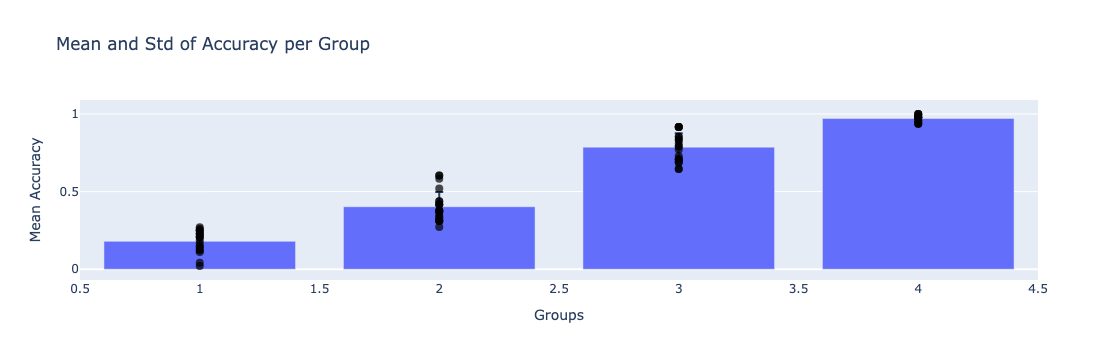

In [442]:
labels = qs

grouped_accs = {group: [] for group in set(labels)}
for group, acc in zip(labels, accs):
    if not pd.isna(acc):
        grouped_accs[group].append(acc)

# print(grouped_accs)
for group in grouped_accs:
    print(group)
    # print(grouped_accs[group])
    print(np.mean(grouped_accs[group]))
    print(np.std(grouped_accs[group]))

# Calculate means and standard deviations
groups = list(grouped_accs.keys())
means = [np.mean(grouped_accs[group]) for group in groups]
stds = [np.std(grouped_accs[group]) for group in groups]

# Create the bar chart
fig = go.Figure()

# Add bars with error bars for standard deviation
fig.add_trace(go.Bar(
    x=groups,
    y=means,
    error_y=dict(type='data', array=stds),  # Add standard deviation as error bars
    name='Mean with Std',
))

# Add scatter plot for individual values
for group in groups:
    fig.add_trace(go.Scatter(
        x=[group] * len(grouped_accs[group]),  # Plot all values under the same group
        y=grouped_accs[group],
        mode='markers',
        name=f'{group} values',
        marker=dict(color='black', size=8, opacity=0.7),
        showlegend=False
    ))


# Update layout
fig.update_layout(
    title='Mean and Std of Accuracy per Group',
    xaxis_title='Groups',
    yaxis_title='Mean Accuracy',
    showlegend=False
)

# Show the plot
fig.show()

## Classification

In [387]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

# Initialize the logistic regression model
clf = LogisticRegression()

# Initialize StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
conf_matrices = []

binary_labels = np.array(ba_topredict)

for train_index, test_index in kf.split(features, binary_labels):
    # Split the data into training and testing sets
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = binary_labels[train_index], binary_labels[test_index]
    
    # Train the model
    clf.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = clf.predict(X_test)
    
    # Calculate accuracy for this fold
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    # Calculate the confusion matrix for this fold
    conf_matrix = confusion_matrix(y_test, y_pred)
    conf_matrices.append(conf_matrix)

# Print out the average accuracy across all folds
average_accuracy = np.mean(accuracies)
print(f"Average Accuracy: {average_accuracy:.2f}")
print(f"std: {np.std(accuracies):.2f}")

# # Print the confusion matrices for each fold
# for i, conf_matrix in enumerate(conf_matrices, 1):
#     print(f"Confusion Matrix for Fold {i}:\n{conf_matrix}")

Average Accuracy: 0.55
std: 0.06


#### Baseline

In [388]:
# Initialize the logistic regression model
clf = LogisticRegression()

# Initialize StratifiedKFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracies = []
conf_matrices = []

binary_labels = np.array(ba_topredict)

for train_index, test_index in kf.split(baseline_features, binary_labels):
    # Split the data into training and testing sets
    X_train, X_test = baseline_features[train_index], baseline_features[test_index]
    y_train, y_test = binary_labels[train_index], binary_labels[test_index]
    
    # Train the model
    clf.fit(X_train, y_train)
    
    # Predict on the test set
    y_pred = clf.predict(X_test)
    
    # Calculate accuracy for this fold
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    
    # Calculate the confusion matrix for this fold
    conf_matrix = confusion_matrix(y_test, y_pred)
    conf_matrices.append(conf_matrix)

# Print out the average accuracy across all folds
average_accuracy = np.mean(accuracies)
print(f"Baseline average Accuracy: {average_accuracy:.2f}")
print(f"std: {np.std(accuracies):.2f}")

Baseline average Accuracy: 0.76
std: 0.08


#### Regression

In [214]:
import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.express as px
import plotly.graph_objects as go
from sklearn.decomposition import PCA

# Initialize and fit the linear regression model
reg = LinearRegression()
reg.fit(features, accs)

# Predict clustering scores based on PCA-1
predicted_scores = reg.predict(features)

# Get the regression coefficient and intercept
slope = reg.coef_
intercept = reg.intercept_

print(f"Linear Regression Coefficients:", slope)
print("""features = [
        num_nodes,
        num_edges,
        depth,
        avg_degree,
        diameter,
        num_leaves,
        avg_path_length,
        avg_branching_factor,
        avg_clustering_coeff
    ]""")
print(f"Intercept: {intercept:.2f}")
print(f"R-squared: {reg.score(features, accs):.2f}")

Linear Regression Coefficients: [ 0.14436111  0.14436111  0.06008946 -0.02383799 -0.14203832 -0.22439522
  0.03209592 -0.02383799]
features = [
        num_nodes,
        num_edges,
        depth,
        avg_degree,
        diameter,
        num_leaves,
        avg_path_length,
        avg_branching_factor,
        avg_clustering_coeff
    ]
Intercept: 0.57
R-squared: 0.06


## Compute heat map thing

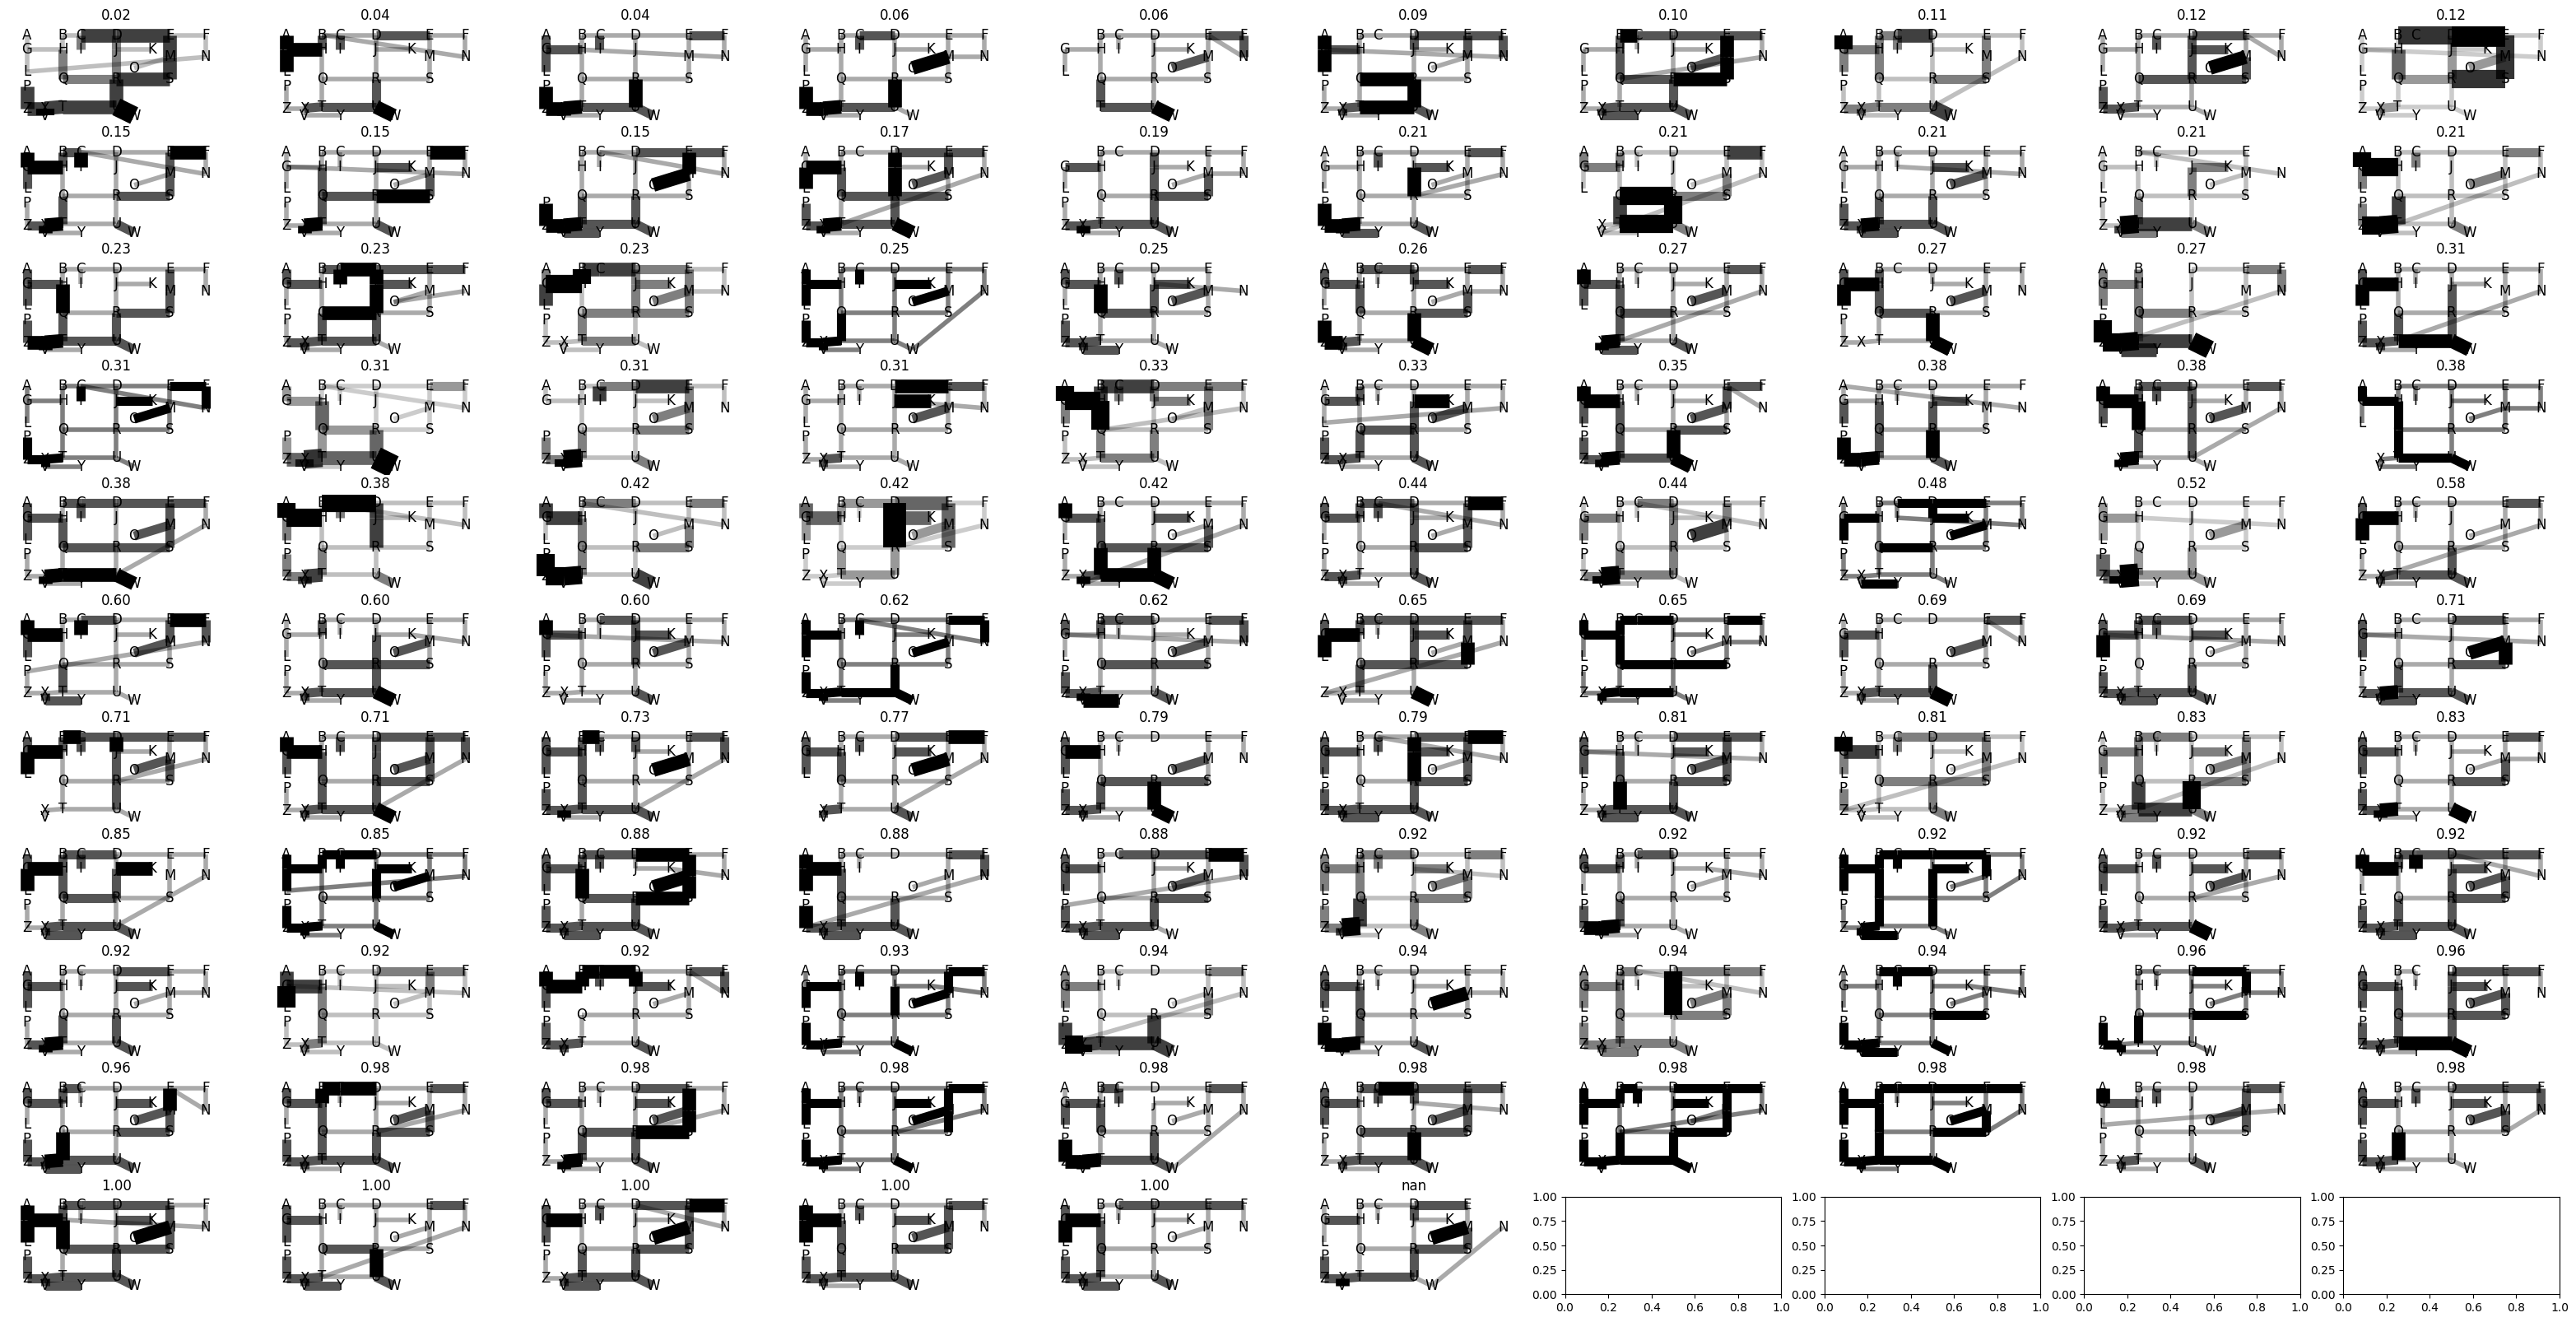

In [346]:
MAZE_SPATIAL_POS = {
    "A": (2, 12), "B": (4, 12), "C": (5, 12),
    "D": (7, 12), "E": (10, 12), "F": (12, 12),
    "G": (2, 10), "H": (4, 10), "I": (5, 10),
    "J": (7, 10), "K": (9, 10), "L": (2, 7),
    "M": (10, 9), "N": (12, 9), "O": (8, 7.5),
    "P": (2, 5), "Q": (4, 6), "R": (7, 6),
    "S": (10, 6), "T": (4, 2.2), "U": (7, 2.2),
    "V": (3, 1), "W": (8, 1), "X": (3, 2),
    "Y": (5, 1), "Z": (2, 2)
}

heat_maps = []
accs = []
for i, row in explore_df.iterrows():
    whole_path = row["e_paths"]
    split_i = row["all_objects_found_idx"]

    # path = collapse_traj([p[0] for p in whole_path[:split_i].split()])
    path = collapse_traj([p[0] for p in whole_path.split()])

    nodes = set()
    edges = {}
    for i, node in enumerate(path):
        nodes.add(node)

        if (i+1) < len(path):
            edge = (node, path[i+1])
            edges[edge] = edges.get(edge, 0) + 1

    G = nx.Graph()
    G.add_nodes_from(nodes)
    for edge in edges:
        G.add_edge(edge[0], edge[1], weight=edges[edge])

    accs.append(row["subject_mean_acc"])
    heat_maps.append(G)

fig, axes = plt.subplots(11, 10, figsize=(40,20))

# print(accs)
sorted_order = sorted(range(len(accs)), key=lambda x: (pd.isna(accs[x]), float(accs[x]) if not pd.isna(accs[x]) else float('inf')))
# print(sorted_order)
for i, tree_index in enumerate(sorted_order):
    ax = axes[i // 10][i % 10]
    G, acc = heat_maps[tree_index], accs[tree_index]
    
    edges = G.edges()
    max_weight = max([G[u][v]['weight'] for u,v in edges])
    weights = [G[u][v]['weight'] * 4 for u,v in edges]
    alphas = [G[u][v]['weight'] / max_weight for u,v in edges]
    nodes = G.nodes()

    n_labels = {n: n for n in G}
    n_colors = ["blue" for n in nodes]

    nx.draw_networkx_edges(G, MAZE_SPATIAL_POS, edgelist=edges, width=weights, alpha=alphas, ax=ax)
    nx.draw_networkx_labels(G, MAZE_SPATIAL_POS, labels=n_labels, font_size=12, ax=ax)
    
    ax.axis("off")
    ax.set_title(f"{acc:.2f}")
    # if i > 10: break

#### Do separate before/after

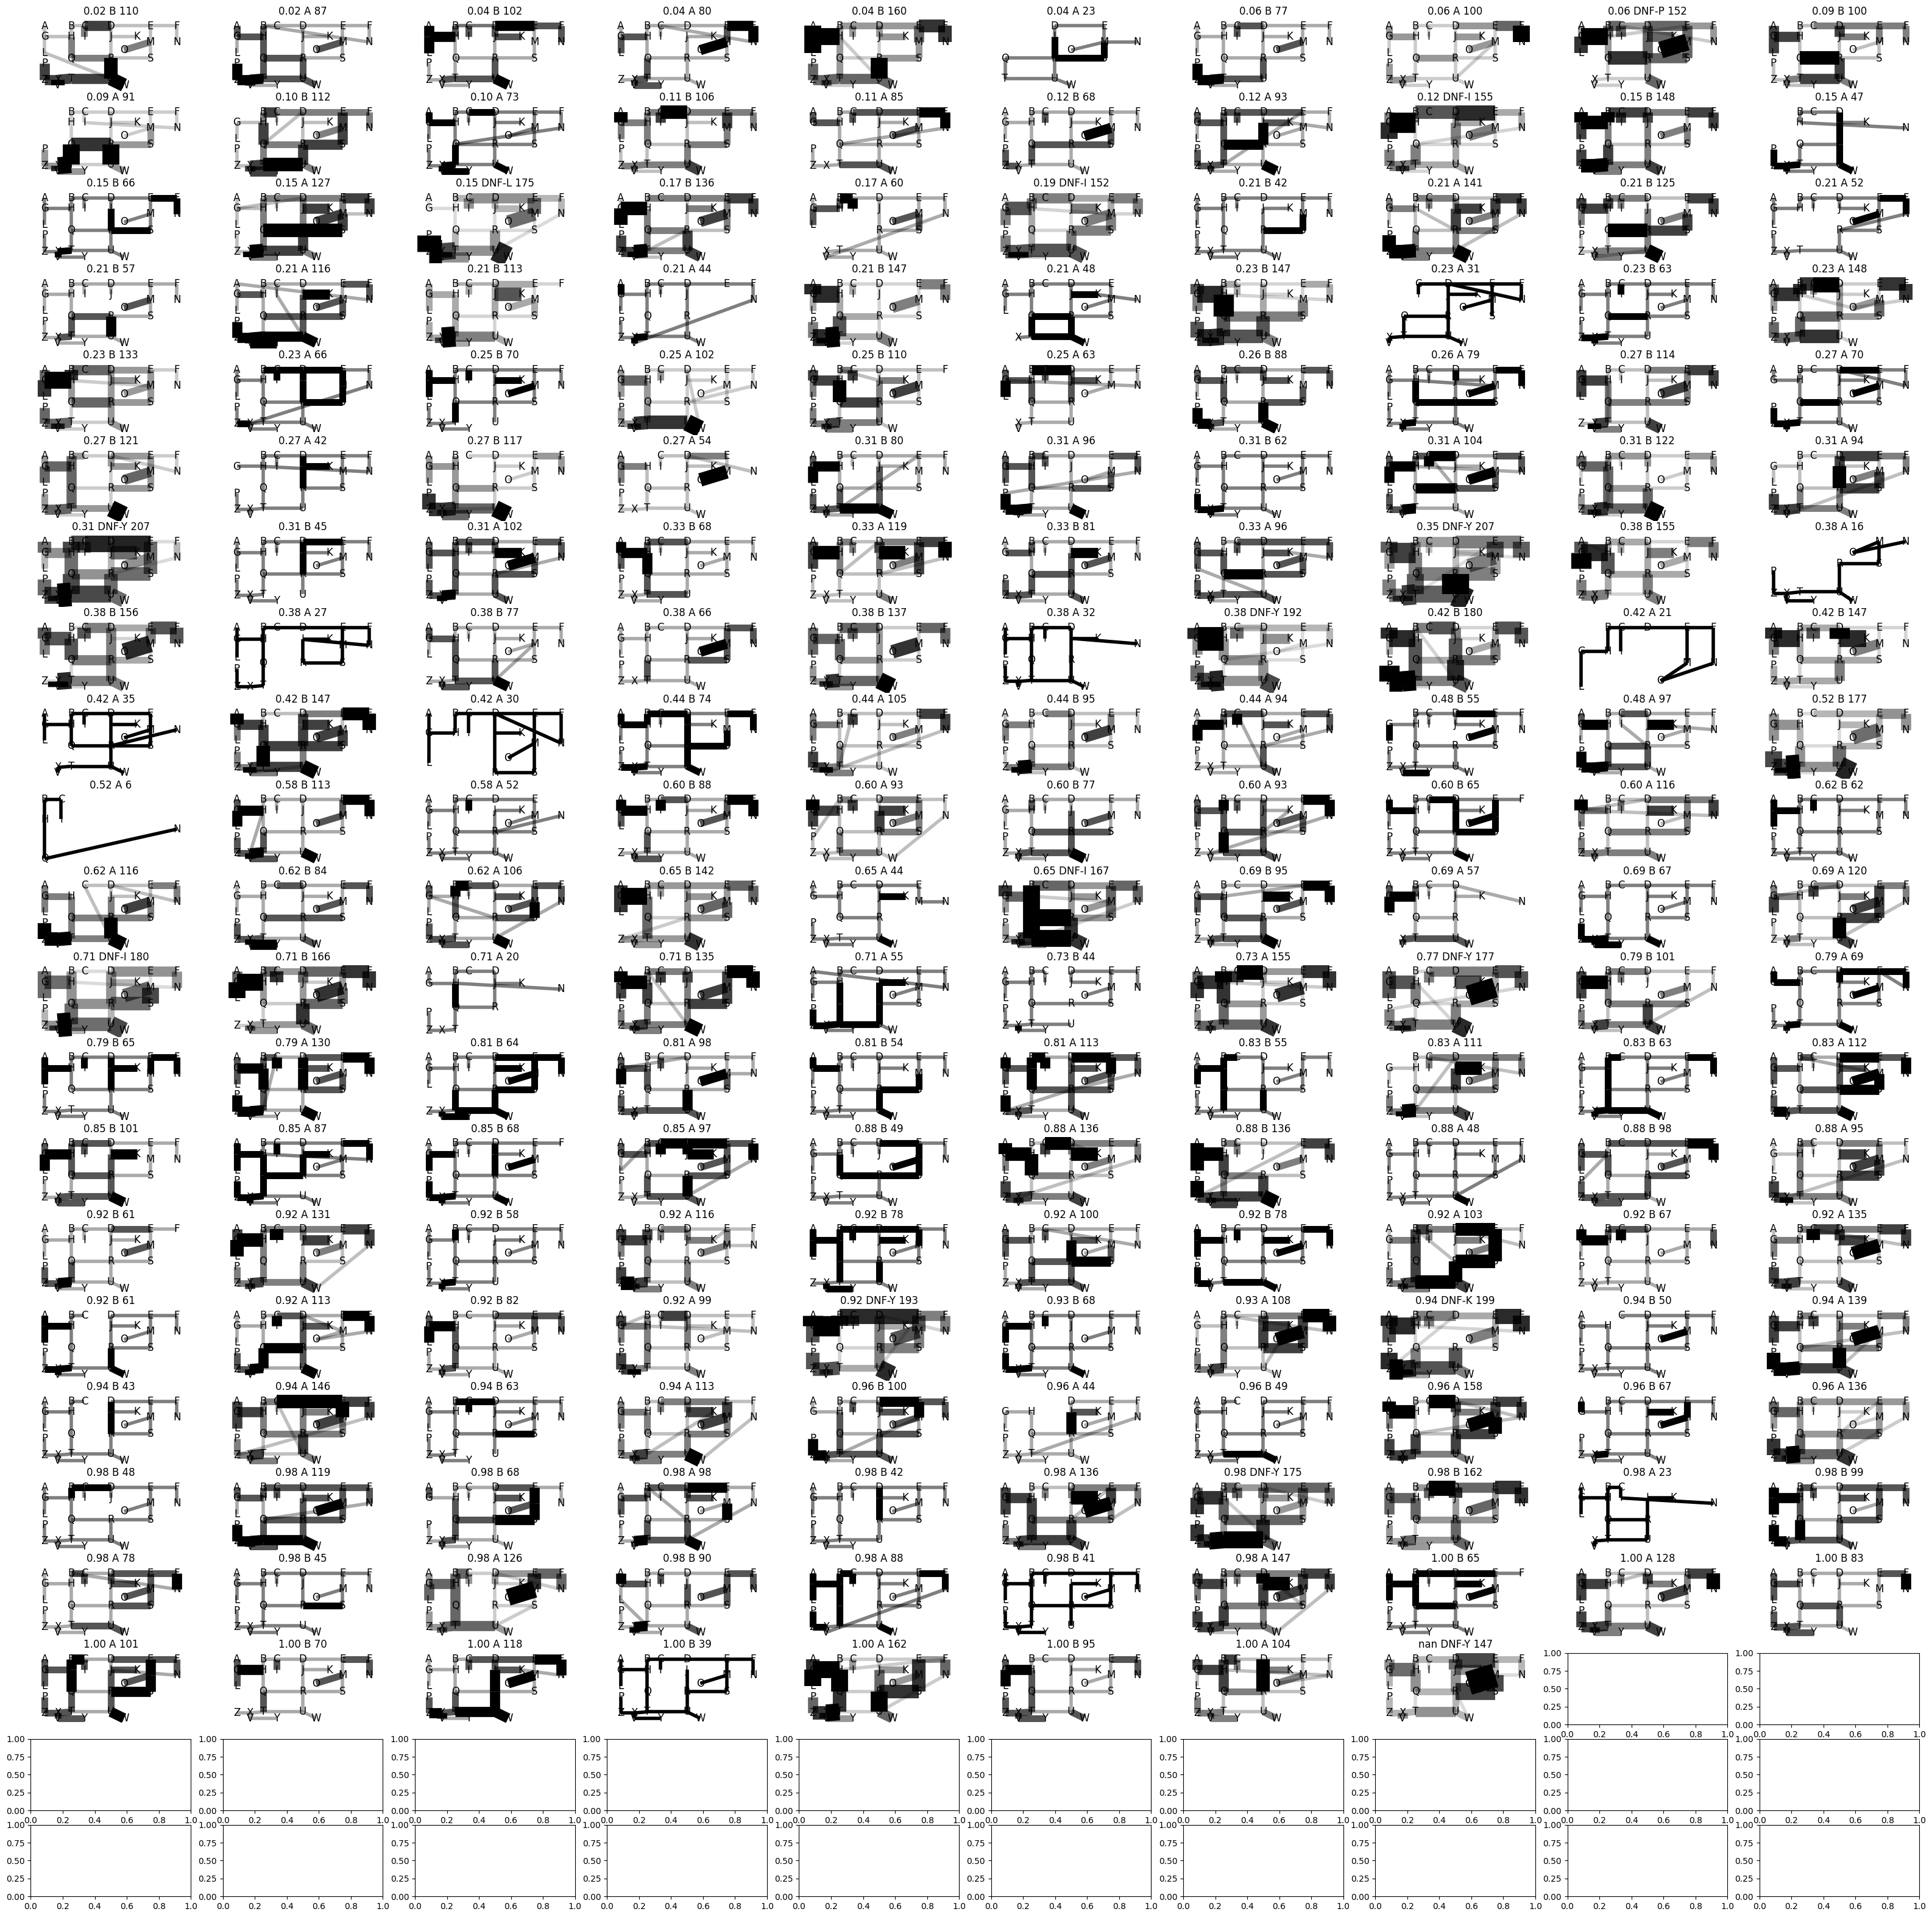

In [347]:
MAZE_SPATIAL_POS = {
    "A": (2, 12), "B": (4, 12), "C": (5, 12),
    "D": (7, 12), "E": (10, 12), "F": (12, 12),
    "G": (2, 10), "H": (4, 10), "I": (5, 10),
    "J": (7, 10), "K": (9, 10), "L": (2, 7),
    "M": (10, 9), "N": (12, 9), "O": (8, 7.5),
    "P": (2, 5), "Q": (4, 6), "R": (7, 6),
    "S": (10, 6), "T": (4, 2.2), "U": (7, 2.2),
    "V": (3, 1), "W": (8, 1), "X": (3, 2),
    "Y": (5, 1), "Z": (2, 2)
}

heat_maps = []
before_after = []
num_nodes = []
accs = []
for i, row in explore_df.iterrows():
    whole_path = row["extended_explore_traj"]
    split_i = row["all_objects_found_idx"]

    if type(split_i) is str:
        path = whole_path
        # if path[-1] == "NA": path.pop(-1)

        path = collapse_traj([p for p in path])
    
        nodes = set()
        edges = {}
        for i, node in enumerate(path):
            nodes.add(node)
    
            if (i+1) < len(path):
                edge = (node, path[i+1])
                edges[edge] = edges.get(edge, 0) + 1
    
        G = nx.Graph()
        G.add_nodes_from(nodes)
        for edge in edges:
            G.add_edge(edge[0], edge[1], weight=edges[edge])
    
        before_after.append(split_i)
        accs.append(row["subject_mean_acc"])
        heat_maps.append(G)
        num_nodes.append(len(path))

    else:
        ## BEFORE ##
        path = collapse_traj([p for p in whole_path[:split_i]])
    
        nodes = set()
        edges = {}
        for i, node in enumerate(path):
            nodes.add(node)
    
            if (i+1) < len(path):
                edge = (node, path[i+1])
                edges[edge] = edges.get(edge, 0) + 1
    
        G = nx.Graph()
        G.add_nodes_from(nodes)
        for edge in edges:
            G.add_edge(edge[0], edge[1], weight=edges[edge])
    
        before_after.append("B")
        accs.append(row["subject_mean_acc"])
        heat_maps.append(G)
        num_nodes.append(len(path))
    
        ## AFTER ##
        after = whole_path[split_i:]
        # print(after)
        # if len(after[0]) == 1: after.pop(0)
        # if after[-1] == "NA": after.pop(-1)
        path = collapse_traj([p for p in after])
    
        nodes = set()
        edges = {}
        for i, node in enumerate(path):
            nodes.add(node)
    
            if (i+1) < len(path):
                edge = (node, path[i+1])
                edges[edge] = edges.get(edge, 0) + 1
    
        G = nx.Graph()
        G.add_nodes_from(nodes)
        for edge in edges:
            G.add_edge(edge[0], edge[1], weight=edges[edge])
    
        before_after.append("A")
        accs.append(row["subject_mean_acc"])
        heat_maps.append(G)
        num_nodes.append(len(path))

fig, axes = plt.subplots(22, 10, figsize=(40,40))

sorted_order = sorted(range(len(accs)), key=lambda x: (pd.isna(accs[x]), float(accs[x]) if not pd.isna(accs[x]) else float('inf')))
for i, tree_index in enumerate(sorted_order):
    ax = axes[i // 10][i % 10]
    G, acc = heat_maps[tree_index], accs[tree_index]
    
    edges = G.edges()
    max_weight = max([G[u][v]['weight'] for u,v in edges])
    weights = [G[u][v]['weight'] * 4 for u,v in edges]
    alphas = [G[u][v]['weight'] / max_weight for u,v in edges]
    nodes = G.nodes()

    n_labels = {n: n for n in G}
    n_colors = ["blue" for n in nodes]

    nx.draw_networkx_edges(G, MAZE_SPATIAL_POS, edgelist=edges, width=weights, alpha=alphas, ax=ax)
    nx.draw_networkx_labels(G, MAZE_SPATIAL_POS, labels=n_labels, font_size=12, ax=ax)
    
    ax.axis("off")
    ax.set_title(f"{acc:.2f} {before_after[tree_index]} {num_nodes[tree_index]}")
    # if i > 10: break